# Import Dataset

In [1]:
!unzip "/content/Sitting Posture v2.v4i.coco.zip" -d "/content/sitting-posture-v2-coco"

unzip:  cannot find or open /content/Sitting Posture v2.v4i.coco.zip, /content/Sitting Posture v2.v4i.coco.zip.zip or /content/Sitting Posture v2.v4i.coco.zip.ZIP.


# Draw Keyjoint

## PyTorch

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
import json
import pandas as pd
import numpy as np
import torchvision
from torchvision.utils import draw_keypoints, make_grid, draw_bounding_boxes
from PIL import Image
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
import cv2

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torchvision.models.detection.keypointrcnn_resnet50_fpn(pretrained=True)
model.eval()

In [ ]:
############################ 
# Adapted 
############################
COCO_SKELETON_0_INDEXED = [
    (1, 0), (2, 0),
    (3, 1), (4, 2),
    (5, 6),
    (5, 7), (6, 8),
    (7, 9), (8, 10),
    (5, 11), (6, 12),
    (11, 13), (12, 14),
    (13, 15), (14, 16)
]
parts = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle"
]
column_names = []
for part in parts:
  column_names.extend([f"{part}_x", f"{part}_y"])
keypoint_data = []
############################ 
#                          #
############################

In [ ]:
with open('/content/sitting-posture-v2-coco/train/_annotations.coco.json', 'r') as f:
    coco_data = json.load(f)

In [ ]:
############################ 
# 
############################
def get_keypoints(image_id):
  #COCO JSON
  img_info = next(item for item in coco_data['images'] if item['id'] == image_id)
  file_name = img_info['file_name']

  ann_info = [item for item in coco_data['annotations'] if item['image_id'] == image_id]

  image_path = os.path.join('/content/sitting-posture-v2-coco/train', file_name)

  img = Image.open(image_path).convert("RGB")
  img_tensor = torch.as_tensor(np.array(img)).permute(2, 0, 1)

  bbox = []
  cat_id = 0
  for ann in ann_info:
    x,y,w,h = ann['bbox']
    cat_id = ann['category_id']
    bbox.append([x,y,x+w,y+h])

  bbox_tensor = torch.tensor(bbox, dtype=torch.float32)
  img_with_boxes = draw_bounding_boxes(img_tensor, bbox_tensor, colors='red',width=2)
  img_for_drawing = F.to_tensor(img).unsqueeze(0).to(device)

  with torch.no_grad():
      output = model(img_for_drawing)[0]

  keypoints = output['keypoints']
  keypoints_scores = output['keypoints_scores'] # score for the coord

  #Skip if empty result
  if (keypoints.shape[0] == 0) : return
  scores = output['scores']

  # 90% con7firm result
  high_score_kp = keypoints[scores > 0.9]
  high_score_kp_scores = keypoints_scores[scores > 0.9]
  #debug
  print(scores)
  print(high_score_kp)

  if high_score_kp.shape[0] == 0: return

  #if more than one
  selected_kp = high_score_kp[0]
  selected_kp_scores = high_score_kp_scores[0]
  print(selected_kp_scores)

  kp_filtered = selected_kp.clone()

  for i in range(17):
    if selected_kp_scores[i] < 0.0:
        kp_filtered[i, :] = torch.tensor([-1, -1, 0])

  #store csv
  data_row = kp_filtered[:, :2].reshape(-1).cpu().numpy()
  df = pd.DataFrame([data_row], columns=column_names)
  df.insert(0, 'image_id', image_id)
  df['cat_id'] = cat_id
  keypoint_data.append(df)

  #draw kp on image

  if len(selected_kp[0]) > 0:
    pred_keypoints, visibility = kp_filtered.split([2, 1], dim=-1)
    visibility = visibility.bool()

    annotated_img = draw_keypoints(
        img_with_boxes,
        pred_keypoints.unsqueeze(0),
        visibility=visibility.unsqueeze(0),
        colors='red',
        radius=4,
        connectivity=COCO_SKELETON_0_INDEXED
    )

  #just tengok
  grid = make_grid(annotated_img)
  grid_np = grid.permute(1, 2, 0).numpy() #(H,W,C)

  plt.figure(figsize=(10, 10))
  plt.imshow(grid_np)
  plt.title("Torch!")
  plt.axis('off')
  plt.show()

  output_filename = "keyjoint_train_dataset/keyjoints_" + os.path.basename(image_path)
  torchvision.io.write_png((annotated_img).to(torch.uint8), output_filename)

In [ ]:
import os

# Create the output directory if it doesn't exist
output_dir = "keyjoint_train_dataset"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

for image_info in coco_data['images']:
    image_id = image_info['id']
    print(f"Processing image ID: {image_id}")
    get_keypoints(image_id=image_id)

In [ ]:
get_keypoints(image_id=2)

In [ ]:
combined_keypoint_df = pd.concat(keypoint_data, ignore_index=True)
combined_keypoint_df.to_csv("keypoint_train_data.csv", index=False)

In [ ]:
!zip -r /content/keyjoint_train_dataset.zip /content/keyjoint_train_dataset

# 1.0 Import Data

In [7]:
# %%capture
!pip -q install torchinfo

In [8]:
# Import Library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision import tv_tensors
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.transforms import functional as F
from torch.amp import GradScaler, autocast
from torchinfo import summary

# Scikit-learn imports
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Additional utilities
import cv2
from tqdm import tqdm
import gc
from collections import Counter
import random

# Check GPU availability
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

In [9]:
with open('_annotations.coco.json', 'r') as f:
    coco_data = json.load(f)

In [ ]:
!unzip "/content/sitting-posture-keyjoint-dataset.zip" -d "/content/sitting-posture-keyjoint-dataset"

In [16]:
train_df = pd.read_csv('sitting-posture-keyjoint-dataset/keyjoint_train_dataset/keypoint_train_data.csv')
valid_df = pd.read_csv('sitting-posture-keyjoint-dataset/keyjoint_valid_dataset/keypoint_valid_data.csv')
test_df = pd.read_csv('sitting-posture-keyjoint-dataset/keyjoint_test_dataset/keypoint_test_data.csv')

# 2.0 EDA and Data Preprocessing

Helper Function

In [4]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [12]:
class SittingPosture(Dataset):
    def __init__(self, data, label):
      self.X = torch.tensor(data, dtype=torch.float32)
      self.y = torch.tensor(label, dtype=torch.long)

    def __len__(self):
      return len(self.X)

    def __getitem__(self, idx):
      X, y = self.X[idx], self.y[idx]
      return X, y

#### Exploratory and Data Analysis

##### Data Description

In [10]:
# Training data information
print("=== TRAIN DATA INFO ===")
print(f"Train data shape: {train_df.shape}")
print(f"Columns: {train_df.columns}")
print(f"Data types: \n{train_df.dtypes}")
print(f"-1 values: \n{(train_df == -1).sum()}")

# Valid data information
print("\n=== TEST DATA INFO ===")
print(f"Train data shape: {valid_df.shape}")
print(f"Columns: {valid_df.columns}")
print(f"-1 values: \n{(valid_df == -1).sum()}")

# Testing data information
print("=== TEST DATA INFO ===")
print(f"Train data shape: {test_df.shape}")
print(f"Columns: {test_df.columns}")
print(f"-1 values: \n{(test_df == -1).sum()}")

=== TRAIN DATA INFO ===
Train data shape: (1317, 36)
Columns: Index(['image_id', 'nose_x', 'nose_y', 'left_eye_x', 'left_eye_y',
       'right_eye_x', 'right_eye_y', 'left_ear_x', 'left_ear_y', 'right_ear_x',
       'right_ear_y', 'left_shoulder_x', 'left_shoulder_y', 'right_shoulder_x',
       'right_shoulder_y', 'left_elbow_x', 'left_elbow_y', 'right_elbow_x',
       'right_elbow_y', 'left_wrist_x', 'left_wrist_y', 'right_wrist_x',
       'right_wrist_y', 'left_hip_x', 'left_hip_y', 'right_hip_x',
       'right_hip_y', 'left_knee_x', 'left_knee_y', 'right_knee_x',
       'right_knee_y', 'left_ankle_x', 'left_ankle_y', 'right_ankle_x',
       'right_ankle_y', 'cat_id'],
      dtype='object')
Data types: 
image_id              int64
nose_x              float64
nose_y              float64
left_eye_x          float64
left_eye_y          float64
right_eye_x         float64
right_eye_y         float64
left_ear_x          float64
left_ear_y          float64
right_ear_x         float64
right

In [18]:
#Split X_train, y_train
X_train = train_df.drop(['cat_id'], axis=1)
y_train = train_df['cat_id']
X_valid = valid_df.drop(['cat_id'], axis=1)
y_valid = valid_df['cat_id']
X_test = test_df.drop(['cat_id'], axis=1)
y_test = test_df['cat_id']

In [12]:
y_train.value_counts()

,count
cat_id,
2,660
1,657


##### Data Visualization (For valid keypoint)

In [13]:
missing_df = (X_train == -1)

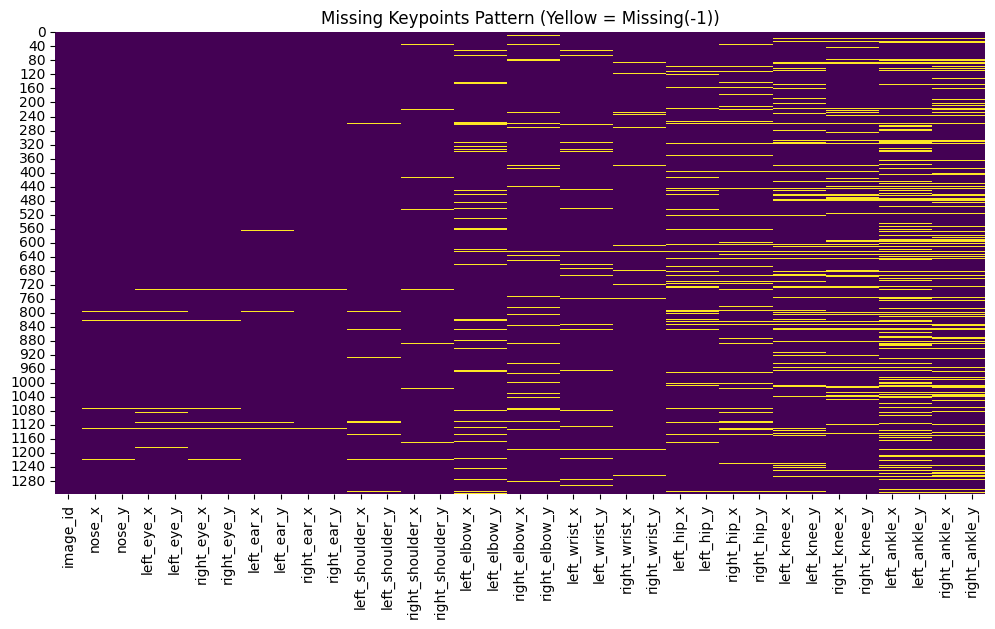

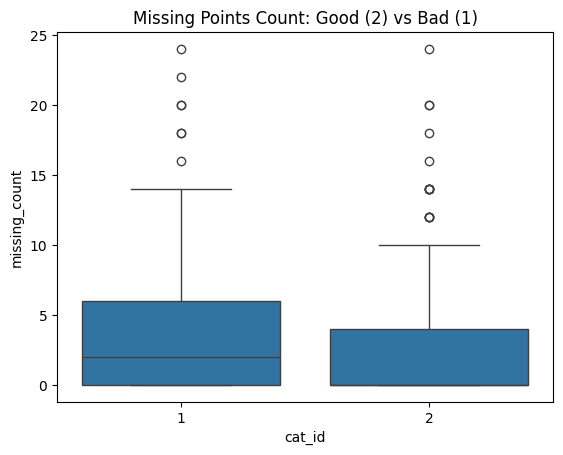

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(missing_df, cbar=False, cmap='viridis')
plt.title("Missing Keypoints Pattern (Yellow = Missing(-1))")
plt.show()

df = train_df.copy()

df['missing_count'] = (df == -1).sum(axis=1)
sns.boxplot(data=df, x='cat_id', y='missing_count')
plt.title("Missing Points Count: Good (2) vs Bad (1)")
plt.show()

1) Since the missing value already replace with (-1,-1), check if any data has too much missing value

In [15]:
value_count_df = train_df.copy()
X_columns = [col for col in value_count_df.columns if '_x' in col]
value_count_df['valid_points_count'] = (value_count_df[X_columns] != -1).sum(axis=1)

print(value_count_df['valid_points_count'].value_counts())

valid_points_count
17    683
16    197
15    193
14     85
13     79
12     37
11     19
10     12
7       4
8       3
5       2
9       2
6       1
Name: count, dtype: int64


From above result, can see than there are some images has less than 10 keypoints.

In [ ]:
filtered_df = value_count_df[value_count_df['valid_points_count'] <= 11]

print("Images with 'valid_points_count' <= 10 and their COCO data:\n")

for index, row in filtered_df.iterrows():
    image_id = int(row['image_id'])
    valid_points_count = row['valid_points_count']

    # Find the corresponding image info in coco_data
    image_info = next((item for item in coco_data['images'] if item['id'] == image_id), None)

    if image_info:
        file_name = image_info['file_name']
        # Correct the image_path to include 'keyjoints_' as part of the filename
        image_path = os.path.join('/content/sitting-posture-keyjoint-dataset/keyjoint_train_dataset', 'keyjoints_' + file_name)
        print(f"Image ID: {image_id}")
        print(f"  File Name: {image_path}")
        print(f"  Valid Points Count: {valid_points_count:.2f}")
        try:
            img = Image.open(image_path)
            plt.figure(figsize=(8, 8)) # Create a new figure for each image
            plt.imshow(img)
            plt.title(f"Image ID: {image_id} - Valid Points Count: {valid_points_count:.2f}")
            plt.axis('off')
            plt.show()
        except FileNotFoundError:
            print(f"  Error: Annotated image not found at {image_path}")
        # You can add more details from row or image_info if needed
        print("------------------------------------------")
    else:
        print(f"Image ID: {image_id} - No matching image info found in coco_data.")
        print(f"  Valid Points Count: {valid_points_count:.2f}")
        print("------------------------------------------")

After checking, consider dropping images with less than 12 valid keypoint

2) Some joint are important to exist (nose, shoulder, hip)

In [17]:
missing_core_df = train_df.copy()
core_joints = ['nose_x', 'left_shoulder_x', 'right_shoulder_x', 'left_hip_x', 'right_hip_x']
is_missing_core = (missing_core_df[core_joints] == -1).any(axis=1)
missing_core_df = missing_core_df[~is_missing_core].copy()
print(f"Delete {is_missing_core.sum()} records")

Delete 180 records


##### Feature Distribution - Nose and shoulder distance

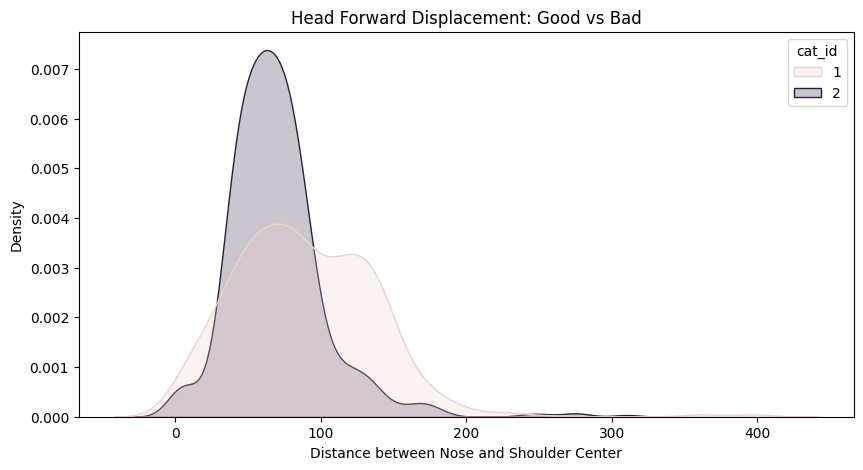

In [14]:
df_valid = train_df[(train_df['nose_x'] != -1) & (train_df['left_shoulder_x'] != -1) & (train_df['right_shoulder_x'] != -1)].copy()

# Calculate shoulder center point
df_valid['sh_center_x'] = (df_valid['left_shoulder_x'] + df_valid['right_shoulder_x']) / 2

df_valid['head_forward'] = abs(df_valid['nose_x'] - df_valid['sh_center_x'])

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_valid, x='head_forward', hue='cat_id', fill=True)
plt.title("Head Forward Displacement: Good vs Bad")
plt.xlabel("Distance between Nose and Shoulder Center")
plt.show()

Display the "weird" image

In [ ]:
filtered_df = df_valid[df_valid['head_forward'] > 150]

print("Images with 'head_forward' > 150 and their COCO data:\n")

for index, row in filtered_df.iterrows():
    image_id = int(row['image_id'])
    head_forward_val = row['head_forward']

    # Find the corresponding image info in coco_data
    image_info = next((item for item in coco_data['images'] if item['id'] == image_id), None)

    if image_info:
        file_name = image_info['file_name']
        # Correct the image_path to include 'keyjoints_' as part of the filename
        image_path = os.path.join('/content/sitting-posture-keyjoint-dataset/keyjoint_train_dataset', 'keyjoints_' + file_name)
        print(f"Image ID: {image_id}")
        print(f"  File Name: {image_path}")
        print(f"  Head Forward: {head_forward_val:.2f}")
        try:
            img = Image.open(image_path)
            plt.figure(figsize=(8, 8)) # Create a new figure for each image
            plt.imshow(img)
            plt.title(f"Image ID: {image_id} - Head Forward: {head_forward_val:.2f}")
            plt.axis('off')
            plt.show()
        except FileNotFoundError:
            print(f"  Error: Annotated image not found at {image_path}")
        # You can add more details from row or image_info if needed
        print("------------------------------------------")
    else:
        print(f"Image ID: {image_id} - No matching image info found in coco_data.")
        print(f"  Head Forward: {head_forward_val:.2f}")
        print("------------------------------------------")

So: Consider dropping images where head_forward > 200

##### Feature Distribution - Left and Right Shoulder Distance

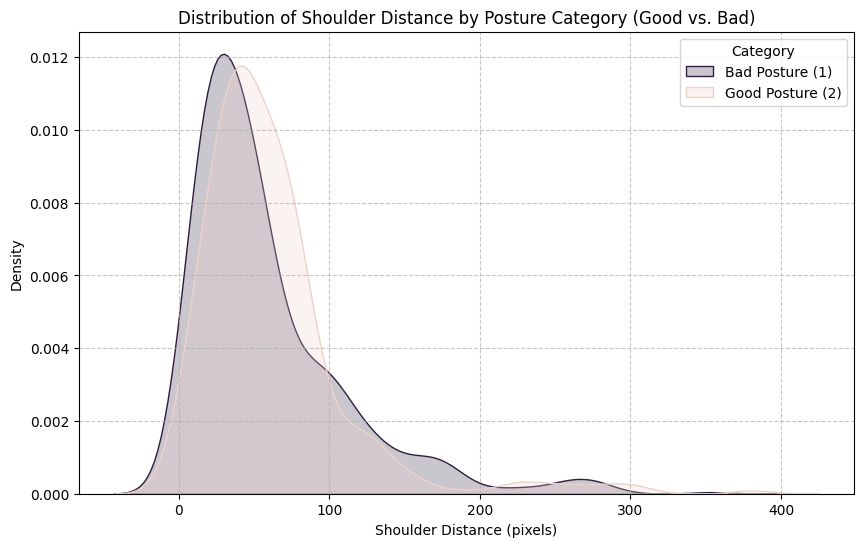

In [20]:
df_shoulder_dist = train_df.copy()

# Calculate shoulder distance, handling cases where shoulder keypoints might be missing (-1)
# Replace -1 with NaN to exclude from calculation and ensure finite values
df_shoulder_dist['left_shoulder_x'] = df_shoulder_dist['left_shoulder_x'].replace(-1, np.nan)
df_shoulder_dist['left_shoulder_y'] = df_shoulder_dist['left_shoulder_y'].replace(-1, np.nan)
df_shoulder_dist['right_shoulder_x'] = df_shoulder_dist['right_shoulder_x'].replace(-1, np.nan)
df_shoulder_dist['right_shoulder_y'] = df_shoulder_dist['right_shoulder_y'].replace(-1, np.nan)

# Only calculate if both left and right shoulder points are present
df_shoulder_dist = df_shoulder_dist.dropna(subset=['left_shoulder_x', 'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y'])

df_shoulder_dist['sh_dist'] = ((df_shoulder_dist['left_shoulder_x'] - df_shoulder_dist['right_shoulder_x'])**2 +
                             (df_shoulder_dist['left_shoulder_y'] - df_shoulder_dist['right_shoulder_y'])**2)**0.5


plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_shoulder_dist, x='sh_dist', hue='cat_id', fill=True, common_norm=False)
plt.title('Distribution of Shoulder Distance by Posture Category (Good vs. Bad)')
plt.xlabel('Shoulder Distance (pixels)')
plt.ylabel('Density')
plt.legend(title='Category', labels=['Bad Posture (1)', 'Good Posture (2)'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [21]:
def is_unusual(row):
  image_id = int(row.image_id)
  sh_dist = ((row.left_shoulder_x - row.right_shoulder_x)**2 +
              (row.left_shoulder_y - row.right_shoulder_y)**2)**0.5

  if sh_dist > 300:
  #if sh_dist > 200 and sh_dist < 300:
    image_info = next((item for item in coco_data['images'] if item['id'] == image_id), None)
    file_name = image_info['file_name']
    image_path = os.path.join('/content/sitting-posture-keyjoint-dataset/keyjoint_train_dataset', 'keyjoints_' + file_name)
    img = Image.open(image_path)
    plt.figure(figsize=(8, 8)) # Create a new figure for each image
    plt.imshow(img)
    plt.title(f"Image ID: {image_id} - Shoulder distance: {sh_dist:.2f}")
    plt.axis('off')
    plt.show()
    return True

  return False

In [ ]:
for row in train_df.itertuples():
  if is_unusual(row):
    print(row)

All images that shoulder distance > 300 are unusual, consider drop it

In [23]:
def is_unusual2(row):
  image_id = int(row["image_id"])
  sh_dist = ((row["left_shoulder_x"] - row["right_shoulder_x"])**2 +
              (row['left_shoulder_y'] - row['right_shoulder_y'])**2)**0.5

  if sh_dist < 1:
    image_info = next((item for item in coco_data['images'] if item['id'] == image_id), None)
    file_name = image_info['file_name']
    image_path = os.path.join('/content/sitting-posture-keyjoint-dataset/keyjoint_train_dataset', 'keyjoints_' + file_name)
    img = Image.open(image_path)
    plt.figure(figsize=(8, 8)) # Create a new figure for each image
    plt.imshow(img)
    plt.title(f"Image ID: {image_id} - Shoulder distance: {sh_dist:.2f}")
    plt.axis('off')
    plt.show()
    return True

  return False

In [ ]:
for index, row_data in train_df.iterrows():
  if is_unusual2(row_data):
    print(row_data)

All images that shoulder distance < 1 are unusual, consider drop it

Average Pose Visualization

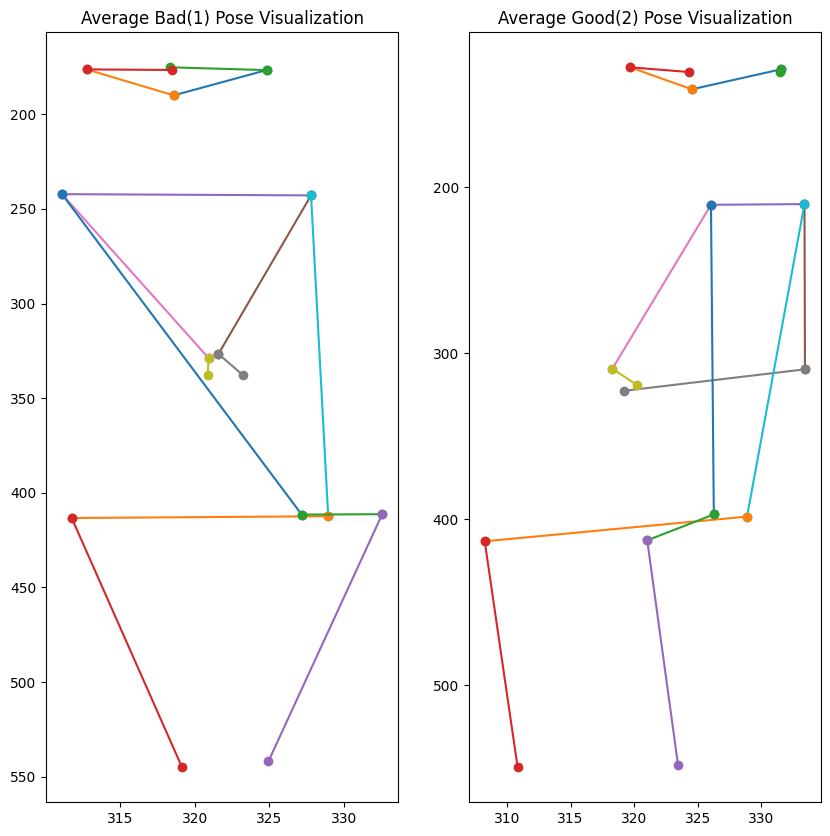

In [25]:
def plot_average_pose(df, title):
  """
  """
  temp = df.replace(-1, pd.NA).dropna(axis=0, how='any')
  mean_coord = temp.mean()

  connections = [
      ('nose_x', 'nose_y', 'left_eye_x', 'left_eye_y'),
      ('nose_x', 'nose_y', 'right_eye_x', 'right_eye_y'),
      ('left_ear_x', 'left_ear_y', 'left_eye_x', 'left_eye_y'),
      ('right_ear_x', 'right_ear_y', 'right_eye_x', 'right_eye_y'),
      ('left_shoulder_x', 'left_shoulder_y', 'right_shoulder_x', 'right_shoulder_y'),
      ('left_shoulder_x', 'left_shoulder_y', 'left_elbow_x', 'left_elbow_y'),
      ('right_shoulder_x', 'right_shoulder_y', 'right_elbow_x', 'right_elbow_y'),
      ('left_elbow_x', 'left_elbow_y', 'left_wrist_x', 'left_wrist_y'),
      ('right_elbow_x', 'right_elbow_y', 'right_wrist_x', 'right_wrist_y'),
      ('left_shoulder_x', 'left_shoulder_y', 'left_hip_x', 'left_hip_y'),
      ('right_shoulder_x', 'right_shoulder_y', 'right_hip_x', 'right_hip_y'),
      ('left_hip_x', 'left_hip_y', 'left_knee_x', 'left_knee_y'),
      ('right_hip_x', 'right_hip_y', 'right_knee_x', 'right_knee_y'),
      ('left_knee_x', 'left_knee_y', 'left_ankle_x', 'left_ankle_y'),
      ('right_knee_x', 'right_knee_y', 'right_ankle_x', 'right_ankle_y')]
  for x1, y1, x2, y2 in connections:
    plt.plot([mean_coord[x1], mean_coord[x2]], [mean_coord[y1], mean_coord[y2]], marker='o')
    plt.gca().invert_yaxis()
    plt.title(title)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plot_average_pose(train_df[train_df['cat_id'] == 1], "Average Bad(1) Pose Visualization")
plt.subplot(1, 2, 2)
plot_average_pose(train_df[train_df['cat_id'] == 2], "Average Good(2) Pose Visualization")
plt.show()

Joint Scatter Plot - Using nose position

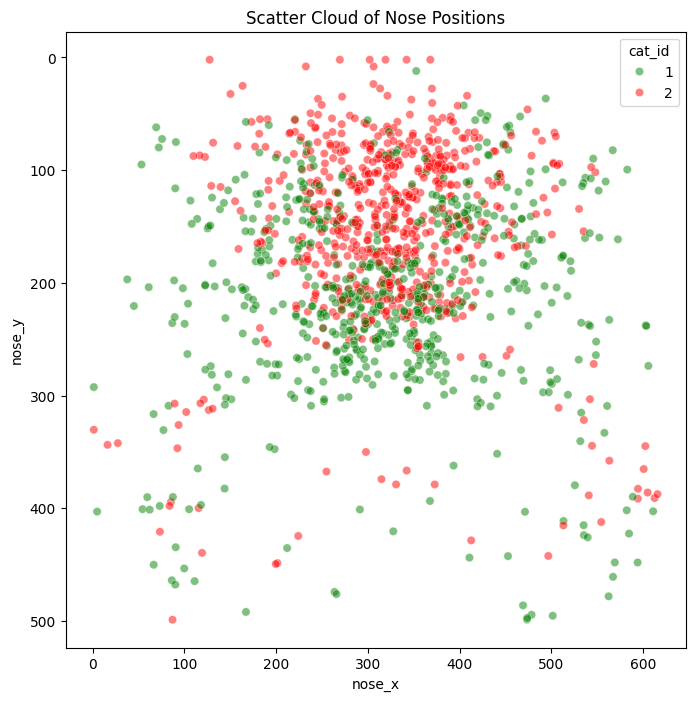

In [26]:
df_nose = train_df[train_df['nose_x'] != -1]

plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_nose, x='nose_x', y='nose_y', hue='cat_id', alpha=0.5, palette=['green', 'red'])
plt.gca().invert_yaxis()
plt.title("Scatter Cloud of Nose Positions")
plt.show()

#### Data Preprocessing

##### Remove unusual rows

Head and Shoulder distance more than 200

In [15]:
# Keep head_forward < 200 in df
filtered_df = df_valid[df_valid['head_forward'] < 200]

original_train_rows = train_df.shape[0]

print(f"Removed {original_train_rows - filtered_df.shape[0]} rows where 'head_forward' was > 200.")

# Update X_train and y_train after filtering
X_train_filtered = filtered_df.drop(['cat_id'], axis=1)
y_train_filtered = filtered_df['cat_id']

print(f"New X_train shape: {X_train_filtered.shape}")
print(f"New y_train shape: {y_train_filtered.shape}")

Removed 78 rows where 'head_forward' was > 200.
New X_train shape: (1239, 37)
New y_train shape: (1239,)


##### Important to exist

In [ ]:
missing_core_df = filtered_df.copy()
core_joints = ['nose_x', 'left_shoulder_x', 'right_shoulder_x', 'left_hip_x', 'right_hip_x']
is_missing_core = (missing_core_df[core_joints] == -1).any(axis=1)
missing_core_df = missing_core_df[~is_missing_core].copy()
print(f"Delete {is_missing_core.sum()} records")

Delete 111 records


Left and Right Shoulder distance more than 300 or less than 1

In [ ]:
def is_unusual_shoulder_dist(row):
  image_id = int(row.image_id)
  if row.left_shoulder_x == -1 or row.right_shoulder_x == -1 or \
     row.left_shoulder_y == -1 or row.right_shoulder_y == -1:
      return False

  sh_dist = ((row.left_shoulder_x - row.right_shoulder_x)**2 +
              (row.left_shoulder_y - row.right_shoulder_y)**2)**0.5

  if sh_dist > 300 or sh_dist < 1:
    return True

  return False

In [ ]:
filtered_df_drop = missing_core_df.copy()

original_train_rows_after_head_filter = train_df.shape[0]

not_unusual_shoulder_mask = ~filtered_df_drop.apply(is_unusual_shoulder_dist, axis=1)

filtered_df_drop = filtered_df_drop[not_unusual_shoulder_mask]

print(f"Removed {original_train_rows_after_head_filter - filtered_df_drop.shape[0]} rows where shoulder distance was > 300 or < 1.")

X_train = filtered_df_drop.drop(['cat_id'], axis=1)
y_train = filtered_df_drop['cat_id']

print(f"Final X_train shape: {X_train.shape}")
print(f"Final y_train shape: {y_train.shape}")

Removed 190 rows where shoulder distance was > 300 or < 1.
Final X_train shape: (1127, 37)
Final y_train shape: (1127,)


In [ ]:
filtered_df_drop_12 = filtered_df_drop.copy()
X_columns = [col for col in filtered_df_drop_12.columns if '_x' in col]
filtered_df_drop_12['valid_points_count'] = (filtered_df_drop_12[X_columns] != -1).sum(axis=1)

filtered_df_drop_12 = filtered_df_drop_12[filtered_df_drop_12['valid_points_count'] > 11]

print(f"Removed {filtered_df_drop.shape[0] - filtered_df_drop_12.shape[0]} rows where valid keypoints <= 11")

X_train = filtered_df_drop_12.drop(['cat_id'], axis=1)
y_train = filtered_df_drop_12['cat_id']

print(f"Final X_train shape: {X_train.shape}")
print(f"Final y_train shape: {y_train.shape}")

Removed 1 rows where valid keypoints <= 11
Final X_train shape: (1126, 38)
Final y_train shape: (1126,)


In [ ]:
filtered_df_drop_12_core = filtered_df_drop_12.copy()
core_joints = ['nose_x', 'left_shoulder_x', 'right_shoulder_x', 'left_hip_x', 'right_hip_x']
is_missing_core = (filtered_df_drop_12_core[core_joints] == -1).any(axis=1)
filtered_df_drop_12_core = filtered_df_drop_12_core[~is_missing_core].copy()
print(f"Delete {is_missing_core.sum()} records")

X_train = filtered_df_drop_12_core.drop(['cat_id'], axis=1)
y_train = filtered_df_drop_12_core['cat_id']

print(f"Final X_train shape: {X_train.shape}")
print(f"Final y_train shape: {y_train.shape}")

Delete 0 records
Final X_train shape: (1126, 38)
Final y_train shape: (1126,)


Visualize Data

In [ ]:
def display_image(row):
  image_id = int(row.image_id)
  image_info = next((item for item in coco_data['images'] if item['id'] == image_id), None)
  file_name = image_info['file_name']
  image_path = os.path.join('/content/sitting-posture-keyjoint-dataset/keyjoint_train_dataset', 'keyjoints_' + file_name)
  img = Image.open(image_path)
  plt.figure(figsize=(8, 8)) # Create a new figure for each image
  plt.imshow(img)
  plt.title(f"Image ID: {image_id}")
  plt.axis('off')
  plt.show()

In [ ]:
for index, row_data in filtered_df_drop_12_core.iterrows():
  display_image(row_data)

After checking, still got 12 images with unusual pattern, manually delete it

In [ ]:
ususual_id_list = [1227,1221,1175,1083,1010,863,672,626,623,614,560,540]
final_df = filtered_df_drop_12_core[~filtered_df_drop_12_core['image_id'].isin(ususual_id_list)]
valid_ids = final_df['image_id']
train_df_cleaned = train_df[train_df['image_id'].isin(valid_ids)].copy()

In [ ]:
X_train = train_df_cleaned.drop(['cat_id'], axis=1)
y_train = train_df_cleaned['cat_id']

print(f"Final X_train shape: {X_train.shape}")
print(f"Final y_train shape: {y_train.shape}")

Final X_train shape: (1114, 35)
Final y_train shape: (1114,)


In [ ]:
y_train.value_counts()

,count
cat_id,
2,575
1,539


##### Normalize 0 ~ 1, for valid keypoint

In [19]:
features = [col for col in X_train.columns if col != 'image_id']

In [20]:
# map -1 to nan
temp_train_train = X_train[features].replace(-1, np.nan)
temp_valid_train = X_valid[features].replace(-1, np.nan)
temp_test_train = X_test[features].replace(-1, np.nan)

In [21]:
scaler = MinMaxScaler()
scaler.fit(temp_train_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [22]:
X_train_norm = X_train.copy()
X_valid_norm = X_valid.copy()
X_test_norm = X_test.copy()

In [23]:
X_train_norm[features] = scaler.transform(temp_train_train)
X_valid_norm[features] = scaler.transform(temp_valid_train)
X_test_norm[features] = scaler.transform(temp_test_train)

In [24]:
X_train_norm = X_train_norm.fillna(-1)
X_valid_norm = X_valid_norm.fillna(-1)
X_test_norm = X_test_norm.fillna(-1)

In [25]:
X_train_norm = X_train_norm.drop(['image_id'], axis=1)
X_valid_norm = X_valid_norm.drop(['image_id'], axis=1)
X_test_norm = X_test_norm.drop(['image_id'], axis=1)

In [26]:
X_train_norm.shape

(1317, 34)

In [27]:
y_train.value_counts()

cat_id
2    660
1    657
Name: count, dtype: int64

# 3.0 Building Models

#### Create Datasets

In [28]:
# Change labels from (1, 2) to (0, 1)
y_train = y_train.values - 1
y_valid = y_valid.values - 1
y_test = y_test.values - 1

In [49]:
train_dataset = SittingPosture(X_train_norm.values, y_train)
valid_dataset = SittingPosture(X_valid_norm.values, y_valid)
test_dataset = SittingPosture(X_test_norm.values, y_test)

In [50]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader =  DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader =  DataLoader(test_dataset, batch_size=32, shuffle=False)

Mini Gradient Descent

In [51]:
# Get a batch of data
x_batch, y_batch = next(iter(train_loader))
print(f"Shape of x_batch: {x_batch.shape}")
print(f"Shape of y_batch: {y_batch.shape}")
# Get a batch of data
x_valid_batch, y_valid_batch = next(iter(valid_loader))
print(f"Shape of x_batch: {x_batch.shape}")
print(f"Shape of y_batch: {y_batch.shape}")
# Get a batch of data
x_test_batch, y_test_batch = next(iter(test_loader))
print(f"Shape of x_batch: {x_batch.shape}")
print(f"Shape of y_batch: {y_batch.shape}")

Shape of x_batch: torch.Size([64, 34])
Shape of y_batch: torch.Size([64])
Shape of x_batch: torch.Size([64, 34])
Shape of y_batch: torch.Size([64])
Shape of x_batch: torch.Size([64, 34])
Shape of y_batch: torch.Size([64])


#### Fully Connected Neuron Network

##### Create FCNN

In [32]:
# Initiate Network
class FCNN(nn.Module):
  def __init__(self):
    """
    Create a Fully Connected Neuron Network

    """
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=34, out_features=64),
        nn.ReLU(),
    )
    self.layer2 = nn.Sequential(
        nn.Linear(in_features=64, out_features=32),
        nn.ReLU(),
    )
    self.outputlayer = nn.Linear(in_features=32, out_features=1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    """
    To perform inference (do prediction).
    During training mode, this will construct the computational graph
    """
    # perform forward propagation and build computational graph
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.outputlayer(x)
    x = self.sigmoid(x)

    return x

In [52]:
# Add BatchNorm
class FCNN(nn.Module):
  def __init__(self):
    """
    Create a Fully Connected Neuron Network

    """
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=34, out_features=64),
        nn.BatchNorm1d(64),
        nn.ReLU()
    )
    self.layer2 = nn.Sequential(
        nn.Linear(in_features=64, out_features=32),
        nn.BatchNorm1d(32),
        nn.ReLU()
    )
    self.outputlayer = nn.Linear(in_features=32, out_features=1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    """
    To perform inference (do prediction).
    During training mode, this will construct the computational graph
    """
    # perform forward propagation and build computational graph
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.outputlayer(x)
    x = self.sigmoid(x)

    return x

In [ ]:
# Add one more layer
class FCNN(nn.Module):
  def __init__(self):
    """
    Create a Fully Connected Neuron Network

    """
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=34, out_features=128),
        nn.BatchNorm1d(128),
        nn.ReLU()
    )
    self.layer2 = nn.Sequential(
        nn.Linear(in_features=128, out_features=64),
        nn.BatchNorm1d(64),
        nn.ReLU()
    )
    self.layer3 = nn.Sequential(
        nn.Linear(in_features=64, out_features=32),
        nn.BatchNorm1d(32),
        nn.ReLU()
    )
    self.outputlayer = nn.Linear(in_features=32, out_features=1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    """
    To perform inference (do prediction).
    During training mode, this will construct the computational graph
    """
    # perform forward propagation and build computational graph
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.outputlayer(x)
    x = self.sigmoid(x)

    return x

In [ ]:
# Change activation function to leaky ReLU
class FCNN(nn.Module):
  def __init__(self):
    """
    Create a Fully Connected Neuron Network

    """
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=34, out_features=128),
        nn.BatchNorm1d(128),
        nn.LeakyReLU(0.1)
    )
    self.layer2 = nn.Sequential(
        nn.Linear(in_features=128, out_features=64),
        nn.BatchNorm1d(64),
        nn.LeakyReLU(0.1)
    )
    self.layer3 = nn.Sequential(
        nn.Linear(in_features=64, out_features=32),
        nn.BatchNorm1d(32),
        nn.LeakyReLU(0.1)
    )
    self.outputlayer = nn.Linear(in_features=32, out_features=1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    """
    To perform inference (do prediction).
    During training mode, this will construct the computational graph
    """
    # perform forward propagation and build computational graph
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.outputlayer(x)
    x = self.sigmoid(x)

    return x

In [ ]:
#Add Dropout???
class FCNN(nn.Module):
  def __init__(self):
    """
    Create a Fully Connected Neuron Network

    """
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(in_features=34, out_features=128),
        nn.BatchNorm1d(128),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
    )
    self.layer2 = nn.Sequential(
        nn.Linear(in_features=128, out_features=64),
        nn.BatchNorm1d(64),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.2)
    )
    self.layer3 = nn.Sequential(
        nn.Linear(in_features=64, out_features=32),
        nn.BatchNorm1d(32),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.2)
    )
    self.outputlayer = nn.Linear(in_features=32, out_features=1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    """
    To perform inference (do prediction).
    During training mode, this will construct the computational graph
    """
    # perform forward propagation and build computational graph
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.outputlayer(x)
    x = self.sigmoid(x)

    return x

In [53]:
fcnn = FCNN()
print(fcnn)

FCNN(
  (layer1): Sequential(
    (0): Linear(in_features=34, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (outputlayer): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [54]:
X_batch, y_batch = next(iter(train_loader))
print(f"Shape of X_batch: {X_batch.shape}")
y_hat = fcnn(X_batch)
print(f"y_hat:\n", y_hat.shape)

Shape of X_batch: torch.Size([64, 34])
y_hat:
 torch.Size([64, 1])


In [55]:
summary(fcnn, input_size=(32, 34), col_names=["input_size", "output_size", "num_params", "mult_adds"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
FCNN                                     [32, 34]                  [32, 1]                   --                        --
├─Sequential: 1-1                        [32, 34]                  [32, 64]                  --                        --
│    └─Linear: 2-1                       [32, 34]                  [32, 64]                  2,240                     71,680
│    └─BatchNorm1d: 2-2                  [32, 64]                  [32, 64]                  128                       4,096
│    └─ReLU: 2-3                         [32, 64]                  [32, 64]                  --                        --
├─Sequential: 1-2                        [32, 64]                  [32, 32]                  --                        --
│    └─Linear: 2-4                       [32, 64]                  [32, 32]                  2,080                     66,560
│    └

##### Cost Function and Optimizer

In [56]:
optimizer = optim.Adam(fcnn.parameters(), lr=0.0001, weight_decay= 1e-3)
loss_function = nn.BCELoss()

# 4.0 Training the Model

Helper Function

In [57]:
def train(train_loader, model, optimizer, loss_function, num_epochs):
    # List to store epoch costs for plotting
    train_epoch_costs = []
    valid_epoch_costs = []

    # For all epochs
    for epoch in range(num_epochs):
        train_batch_costs = []
        valid_batch_costs = []

        # set to training mode
        model.train()

        # ===== TRAIN ======
        for x_batch, y_batch in train_loader:

            # transfer batch data to the GPU if available
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Reshape y_batch's shape = y_hat's shape (B, 1)
            y_batch = y_batch.unsqueeze(1).float()

            # Forward propagation
            y_hat = model(x_batch) # shape = (B,1)

            # Compute cost
            cost = loss_function(y_hat, y_batch)
            train_batch_costs.append(cost.item())

            # Backward propagation
            cost.backward()

            # Update parameters
            optimizer.step()

            # Reset the gradient
            optimizer.zero_grad()
          # ===== END OF TRAIN ======

        # set to evaluation mode
        model.eval()

        # ===== VALIDATION ======
        with torch.inference_mode():
          for x_batch, y_batch in valid_loader:
            best_val_loss = 0.0
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_batch = y_batch.unsqueeze(1).float()

            y_hat = model(x_batch) # shape = (B,1)

            # Compute cost
            cost = loss_function(y_hat, y_batch)
            valid_batch_costs.append(cost.item())
            if cost > best_val_loss:
              best_val_loss = cost
              torch.save(model.state_dict(), 'best_model.pth')
        # ===== END OF VALIDATION ======

        # Calculate average cost for the epoch
        avg_train_epoch_cost = sum(train_batch_costs) / len(train_batch_costs)
        avg_valid_epoch_cost = sum(valid_batch_costs) / len(valid_batch_costs)
        train_epoch_costs.append(avg_train_epoch_cost)
        valid_epoch_costs.append(avg_valid_epoch_cost)

        if (epoch + 1) % (num_epochs//10) == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], average train cost: {avg_train_epoch_cost:.4f}, average val cost: {avg_valid_epoch_cost:.4f}")

    # Plotting the cost
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs + 1), train_epoch_costs, marker='o', linestyle='-', color='blue')
    plt.plot(range(1, num_epochs + 1), valid_epoch_costs, marker='x', linestyle='-', color='red')
    plt.title('Training & Validation Cost per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.grid(True)
    plt.show()

#### Fully Connected Neuron Network

In [58]:
set_seed(6)

Epoch [5/50], average train cost: 0.4805, average val cost: 0.5244
Epoch [10/50], average train cost: 0.4669, average val cost: 0.5162
Epoch [15/50], average train cost: 0.4565, average val cost: 0.5048
Epoch [20/50], average train cost: 0.4341, average val cost: 0.5039
Epoch [25/50], average train cost: 0.4228, average val cost: 0.4982
Epoch [30/50], average train cost: 0.4086, average val cost: 0.4906
Epoch [35/50], average train cost: 0.3981, average val cost: 0.4859
Epoch [40/50], average train cost: 0.3804, average val cost: 0.4807
Epoch [45/50], average train cost: 0.3803, average val cost: 0.4820
Epoch [50/50], average train cost: 0.3579, average val cost: 0.4720


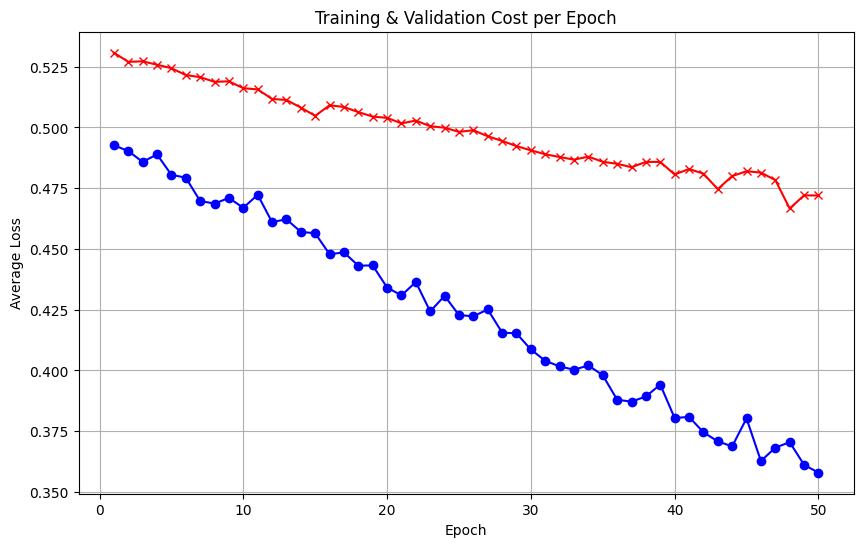

In [60]:
train(train_loader=train_loader, model=fcnn, optimizer=optimizer, loss_function=loss_function, num_epochs=50)

# 5.0 Model Evaluation

#### Fully Connected Neuron Network

In [61]:
def evaluate(data_loader, net):
    correct = 0
    total = 0

    # Set the model to evaluation mode
    net.eval()

    # Disable gradient computation
    with torch.inference_mode():

        # Repeat for all batch data
         for x_batch, y_batch in data_loader:

            # transfer to GPU
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # predict class scores
            y_hat = net(x_batch)
            y_hat = y_hat.squeeze()
            y_pred = (y_hat > 0.5).float()

            # accumulate to total and correct
            total   += y_batch.size(0)
            correct += (y_pred == y_batch).sum().item()

    # compute accuracy
    acc = correct / total
    return acc

In [62]:
fcnn.load_state_dict(torch.load('best_model.pth'))
fcnn.eval()

FCNN(
  (layer1): Sequential(
    (0): Linear(in_features=34, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer2): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (outputlayer): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [63]:
test_acc = evaluate(valid_loader, fcnn)
print(f"t_acc = {test_acc * 100:.2f}%")

t_acc = 81.56%


In [64]:
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in valid_loader:
        inputs = inputs.to(device)
        outputs = fcnn(inputs)
        predicted = (outputs > 0.5).squeeze().numpy()
        all_preds.extend(predicted)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds))


              precision    recall  f1-score   support

           0       0.80      0.84      0.82        88
           1       0.84      0.79      0.81        91

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



# 6.0 Comparison between models